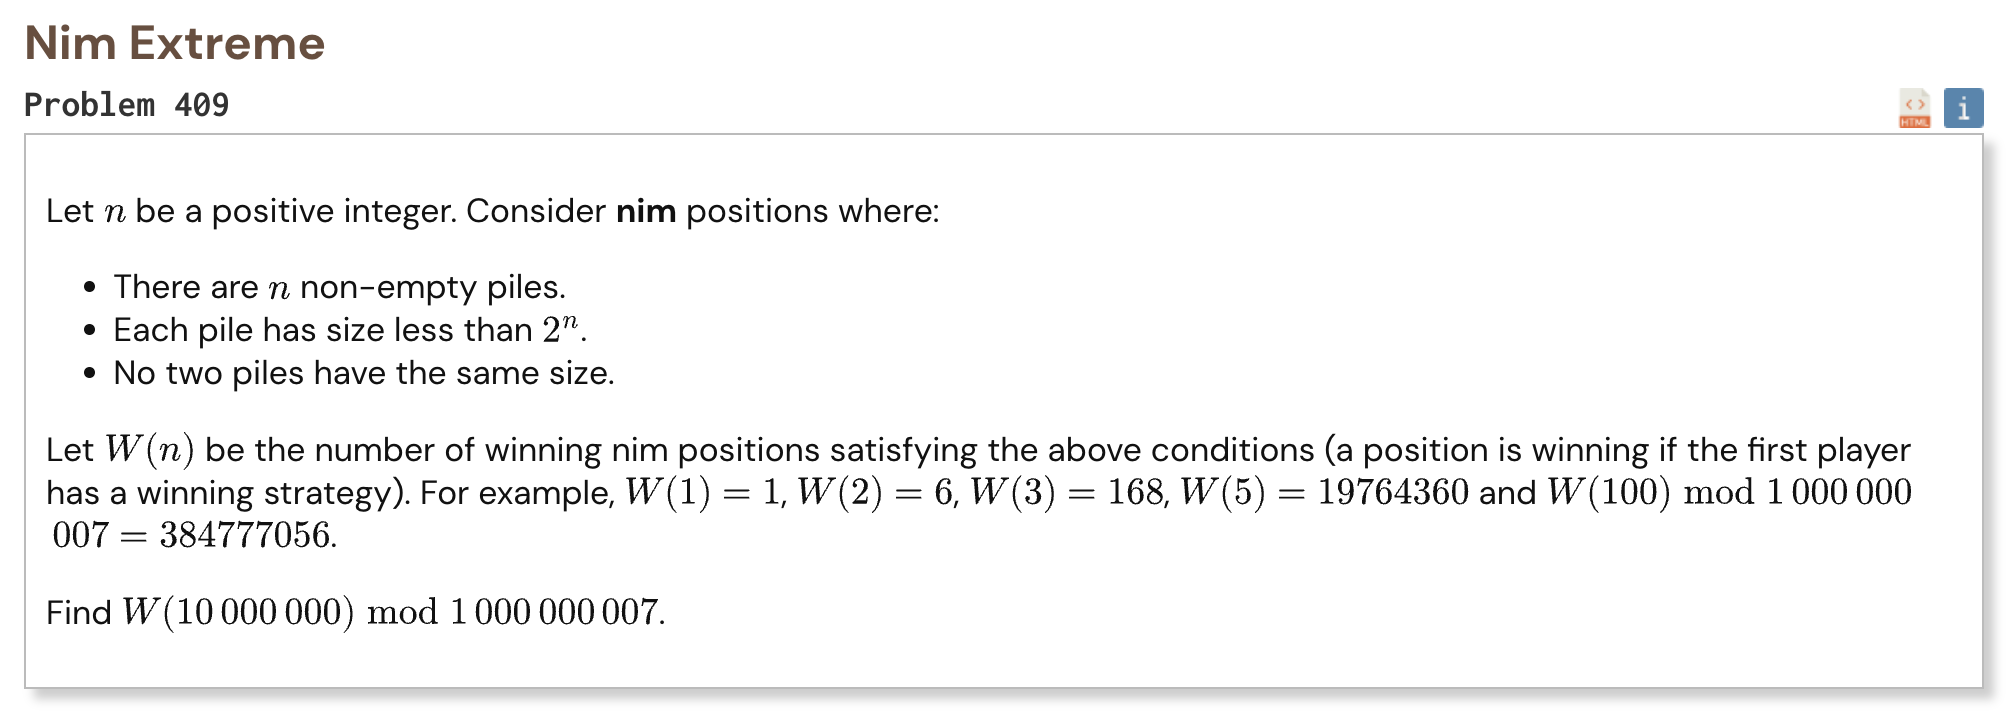

## Initial approach

-   represent every pile size as a binary vector
-   a nim position is losing only when all pile vectors combine to zero
-   count every ordered selection of distinct nonzero pile sizes
-   use binary symmetry to count the selections whose combined value is zero
-   calculate the required combination using a short falling product
-   subtract the losing positions from all possible positions
-   keep only a few modular values so memory usage stays constant

In [1]:
%%time

MOD = 1_000_000_007

def winning_positions(n):
    number_of_sizes = pow(2, n, MOD)
    half = n // 2

    total_positions = 1
    factorial = 1
    half_factorial = 1

    for value in range(1, n + 1):
        total_positions *= number_of_sizes - value
        total_positions %= MOD

        factorial *= value
        factorial %= MOD

        if value == half:
            half_factorial = factorial

    half_size_count = pow(2, n - 1, MOD)
    numerator = 1

    for value in range(half):
        numerator *= half_size_count - 1 - value
        numerator %= MOD

    combination = numerator
    combination *= pow(half_factorial, MOD - 2, MOD)
    combination %= MOD

    contribution = factorial * combination % MOD

    if ((n + 1) // 2) % 2 == 1:
        contribution = -contribution % MOD

    losing_positions = total_positions
    losing_positions += (number_of_sizes - 1) * contribution
    losing_positions %= MOD

    inverse_size_count = pow(number_of_sizes, MOD - 2, MOD)
    losing_positions *= inverse_size_count
    losing_positions %= MOD

    return (total_positions - losing_positions) % MOD

result = winning_positions(10_000_000)
print("Result:", result)

Result: 253223948
CPU times: user 1.85 s, sys: 9.27 ms, total: 1.86 s
Wall time: 1.86 s
